In [ ]:
# ============================================================
# CELL 1: Mount Drive, Create Project Structure, Verify GPU
# ============================================================

# Mount Google Drive — a popup will ask you to authorize access.
# Click "Connect to Google Drive" → pick your account → Allow.
from google.colab import drive
drive.mount('/content/drive')

import os
import torch

# --- Project root (everything lives here) ---
PROJECT_ROOT = '/content/drive/MyDrive/FinDocVQA'

# --- Create folder structure ---
folders = [
    'notebooks',
    'data/docvqa',
    'data/chartqa',
    'data/tatqa',
    'data/financial_test/images',
    'data/financial_test/annotations',
    'models',
    'outputs',
    'configs',
]

for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(path, exist_ok=True)
    print(f"✓ {path}")

# --- Verify GPU ---
print("\n" + "="*50)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✓ GPU available: {gpu_name}")
    print(f"  Memory: {gpu_mem:.1f} GB")
else:
    print("✗ NO GPU DETECTED — go to Runtime → Change runtime type → T4 GPU")

print(f"  PyTorch version: {torch.__version__}")
print("="*50)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ /content/drive/MyDrive/FinDocVQA/notebooks
✓ /content/drive/MyDrive/FinDocVQA/data/docvqa
✓ /content/drive/MyDrive/FinDocVQA/data/chartqa
✓ /content/drive/MyDrive/FinDocVQA/data/tatqa
✓ /content/drive/MyDrive/FinDocVQA/data/financial_test/images
✓ /content/drive/MyDrive/FinDocVQA/data/financial_test/annotations
✓ /content/drive/MyDrive/FinDocVQA/models
✓ /content/drive/MyDrive/FinDocVQA/outputs
✓ /content/drive/MyDrive/FinDocVQA/configs

✓ GPU available: Tesla T4
  Memory: 15.6 GB
  PyTorch version: 2.10.0+cu128


In [ ]:
# ============================================================
# CELL 2: Install All Dependencies
# ============================================================
# This takes 2-3 minutes. You only need to run it once per
# runtime session (it resets when your Colab disconnects).
# ============================================================

%%capture install_output
# %%capture hides the noisy install logs. Remove it if you want to debug.

!pip install --upgrade pip

# Core ML
!pip install transformers==4.44.2
!pip install peft==0.12.0
!pip install datasets==2.20.0
!pip install evaluate==0.4.2
!pip install accelerate==0.33.0
!pip install bitsandbytes==0.43.1

# OCR (for baseline + LayoutLMv3)
!pip install pytesseract
!apt-get -qq install tesseract-ocr

# Image processing
!pip install pdf2image
!apt-get -qq install poppler-utils
!pip install Pillow

# Experiment tracking
!pip install wandb

# Demo UI (needed later, but install now)
!pip install gradio

# Data & visualization
!pip install pandas matplotlib seaborn

# Misc
!pip install sentencepiece  # needed by some tokenizers
!pip install protobuf       # needed by Pix2Struct

print("✓ All dependencies installed successfully!")


In [ ]:
# ============================================================
# CELL 2b: Fix NumPy compatibility
# ============================================================
!pip install numpy==1.26.4

In [ ]:
# ============================================================
# CELL 3: Verify All Imports
# ============================================================
# If any import fails here, you know exactly what broke.
# ============================================================

# Core ML
import torch
import transformers
from transformers import AutoTokenizer, AutoModel, AutoProcessor
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import evaluate
import accelerate

# OCR
import pytesseract

# Image
from PIL import Image

# Data & viz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tracking
import wandb

# Standard lib
import json
import os
from pathlib import Path
from collections import Counter

# Print versions of critical packages
print("Package versions:")
print(f"  torch:        {torch.__version__}")
print(f"  transformers: {transformers.__version__}")
print(f"  CUDA:         {torch.version.cuda}")
print(f"  GPU:          {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print()
print("✓ All imports successful — environment is ready!")


Package versions:
  torch:        2.10.0+cu128
  transformers: 4.44.2
  CUDA:         12.8
  GPU:          Tesla T4

✓ All imports successful — environment is ready!


In [ ]:
# ============================================================
# CELL 4: Project Config (reuse this in every notebook)
# ============================================================
# This cell defines all paths and constants in one place.
# Copy this cell into every new notebook you create.
# ============================================================

import os

class Config:
    """Central config for the entire project."""

    # --- Paths ---
    PROJECT_ROOT    = '/content/drive/MyDrive/FinDocVQA'
    DATA_DIR        = os.path.join(PROJECT_ROOT, 'data')
    DOCVQA_DIR      = os.path.join(DATA_DIR, 'docvqa')
    CHARTQA_DIR     = os.path.join(DATA_DIR, 'chartqa')
    TATQA_DIR       = os.path.join(DATA_DIR, 'tatqa')
    FINANCIAL_DIR   = os.path.join(DATA_DIR, 'financial_test')
    FINANCIAL_IMGS  = os.path.join(FINANCIAL_DIR, 'images')
    FINANCIAL_ANNOT = os.path.join(FINANCIAL_DIR, 'annotations')
    MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models')
    OUTPUTS_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
    CONFIGS_DIR     = os.path.join(PROJECT_ROOT, 'configs')

    # --- Model HuggingFace IDs ---
    LAYOUTLMV3_ID  = 'microsoft/layoutlmv3-base'
    DONUT_ID       = 'naver-clova-ix/donut-base'
    PIX2STRUCT_ID  = 'google/pix2struct-docvqa-base'

    # --- Training hyperparameters ---
    LORA_RANK      = 16
    LORA_ALPHA     = 32
    LEARNING_RATE  = 5e-5
    WEIGHT_DECAY   = 0.01
    EPOCHS         = 15
    PATIENCE       = 3
    BATCH_SIZE     = 8
    MAX_SEQ_LEN    = 512

    # --- Evaluation ---
    NUMERICAL_TOLERANCE = 0.01  # 1% tolerance for numerical accuracy

    # --- Seed for reproducibility ---
    SEED = 42

cfg = Config()

# Quick sanity check
assert os.path.exists(cfg.PROJECT_ROOT), \
    f"Project root not found: {cfg.PROJECT_ROOT}. Did you run Cell 1?"

print("✓ Config loaded. Project root:", cfg.PROJECT_ROOT)


✓ Config loaded. Project root: /content/drive/MyDrive/FinDocVQA


In [ ]:
# ============================================================
# CELL 5: Download ChartQA from HuggingFace
# ============================================================

from datasets import load_dataset
import json

print("Downloading ChartQA... (this takes 1-2 minutes)")
chartqa = load_dataset("HuggingFaceM4/ChartQA")

# See what we got
print("\nChartQA splits:")
for split_name, split_data in chartqa.items():
    print(f"  {split_name}: {len(split_data)} examples")

print("\nColumn names:", chartqa['train'].column_names)

# Look at one example
print("\nSample example:")
example = chartqa['train'][0]
for key, val in example.items():
    if key == 'image':
        print(f"  image: <PIL Image, size={val.size}>")
    else:
        print(f"  {key}: {val}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]


ChartQA splits:
  train: 28299 examples
  val: 1920 examples
  test: 2500 examples

Column names: ['image', 'query', 'label', 'human_or_machine']

Sample example:
  image: <PIL Image, size=(422, 359)>
  query: Is the value of Favorable 38 in 2015?
  label: ['Yes']
  human_or_machine: 0


In [ ]:
# ============================================================
# CELL 5b: Download DocVQA from HuggingFace (pixparse mirror)
# ============================================================

from datasets import load_dataset

print("Downloading DocVQA... (this is ~6GB, takes 5-10 minutes)")
docvqa = load_dataset("pixparse/docvqa-single-page-questions")

# See what we got
print("\nDocVQA splits:")
for split_name, split_data in docvqa.items():
    print(f"  {split_name}: {len(split_data)} examples")

print("\nColumn names:", docvqa['train'].column_names)

# Look at one example
print("\nSample example:")
example = docvqa['train'][0]
for key, val in example.items():
    if key == 'image':
        print(f"  image: {type(val)}")
    elif key == 'ocr_results':
        print(f"  ocr_results: <present, {len(str(val))} chars>")
    elif key == 'other_metadata':
        print(f"  other_metadata: <present>")
    else:
        print(f"  {key}: {val}")

print("\n✓ DocVQA loaded successfully!")

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/39463 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5349 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5188 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/35 [00:00<?, ?it/s]


DocVQA splits:
  train: 39463 examples
  validation: 5349 examples
  test: 5188 examples

Column names: ['image', 'question_id', 'question', 'answers', 'data_split', 'ocr_results', 'other_metadata']

Sample example:
  image: <class 'PIL.PngImagePlugin.PngImageFile'>
  question_id: 9951
  question: When is the contract effective date?
  answers: ['7 - 1 - 99']
  data_split: train
  ocr_results: <present, 58802 chars>
  other_metadata: <present>

✓ DocVQA loaded successfully!


In [ ]:
# ============================================================
# CELL 6: Download TAT-QA from GitHub
# ============================================================

import os
import json

TATQA_DIR = cfg.TATQA_DIR

# Clone the repo to Colab's local storage (faster than Drive)
!rm -rf /content/TAT-QA
!git clone https://github.com/NExTplusplus/TAT-QA.git /content/TAT-QA

# See what's in the dataset folder
print("TAT-QA repo contents:")
!ls /content/TAT-QA/dataset_raw/

# Load and inspect the training set
with open('/content/TAT-QA/dataset_raw/tatqa_dataset_train.json', 'r') as f:
    tatqa_train = json.load(f)

with open('/content/TAT-QA/dataset_raw/tatqa_dataset_dev.json', 'r') as f:
    tatqa_dev = json.load(f)

print(f"\nTAT-QA train: {len(tatqa_train)} contexts")
print(f"TAT-QA dev:   {len(tatqa_dev)} contexts")

# Count total questions
train_q = sum(len(ctx.get('questions', [])) for ctx in tatqa_train)
dev_q = sum(len(ctx.get('questions', [])) for ctx in tatqa_dev)
print(f"\nTotal train questions: {train_q}")
print(f"Total dev questions:   {dev_q}")

# Look at one context
sample = tatqa_train[0]
print(f"\nSample context keys: {list(sample.keys())}")
print(f"Number of questions in this context: {len(sample.get('questions', []))}")

# Show first question
if sample.get('questions'):
    q = sample['questions'][0]
    print(f"\nFirst question:")
    for k, v in q.items():
        print(f"  {k}: {v}")

# Copy the JSON files to Drive for persistence
import shutil
for fname in ['tatqa_dataset_train.json', 'tatqa_dataset_dev.json']:
    src = f'/content/TAT-QA/dataset_raw/{fname}'
    dst = os.path.join(TATQA_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"\n✓ Copied {fname} to Drive")

Cloning into '/content/TAT-QA'...
remote: Enumerating objects: 476, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 476 (delta 218), reused 174 (delta 120), pack-reused 189 (from 1)
Receiving objects: 100% (476/476), 4.84 MiB | 20.40 MiB/s, done.
Resolving deltas: 100% (291/291), done.
TAT-QA repo contents:
tatqa_dataset_dev.json	      tatqa_dataset_test.json
tatqa_dataset_test_gold.json  tatqa_dataset_train.json

TAT-QA train: 2201 contexts
TAT-QA dev:   278 contexts

Total train questions: 13215
Total dev questions:   1668

Sample context keys: ['table', 'paragraphs', 'questions']
Number of questions in this context: 6

First question:
  uid: 9c569bea-e036-4c27-8e41-82c6efab1d31
  order: 1
  question: What does the Weighted average actuarial assumptions consist of?
  answer: ['Rate of inflation', 'Rate of increase in salaries', 'Discount rate']
  derivation: 
  answer_type: multi-span
  answer_from: table
  rel_pa

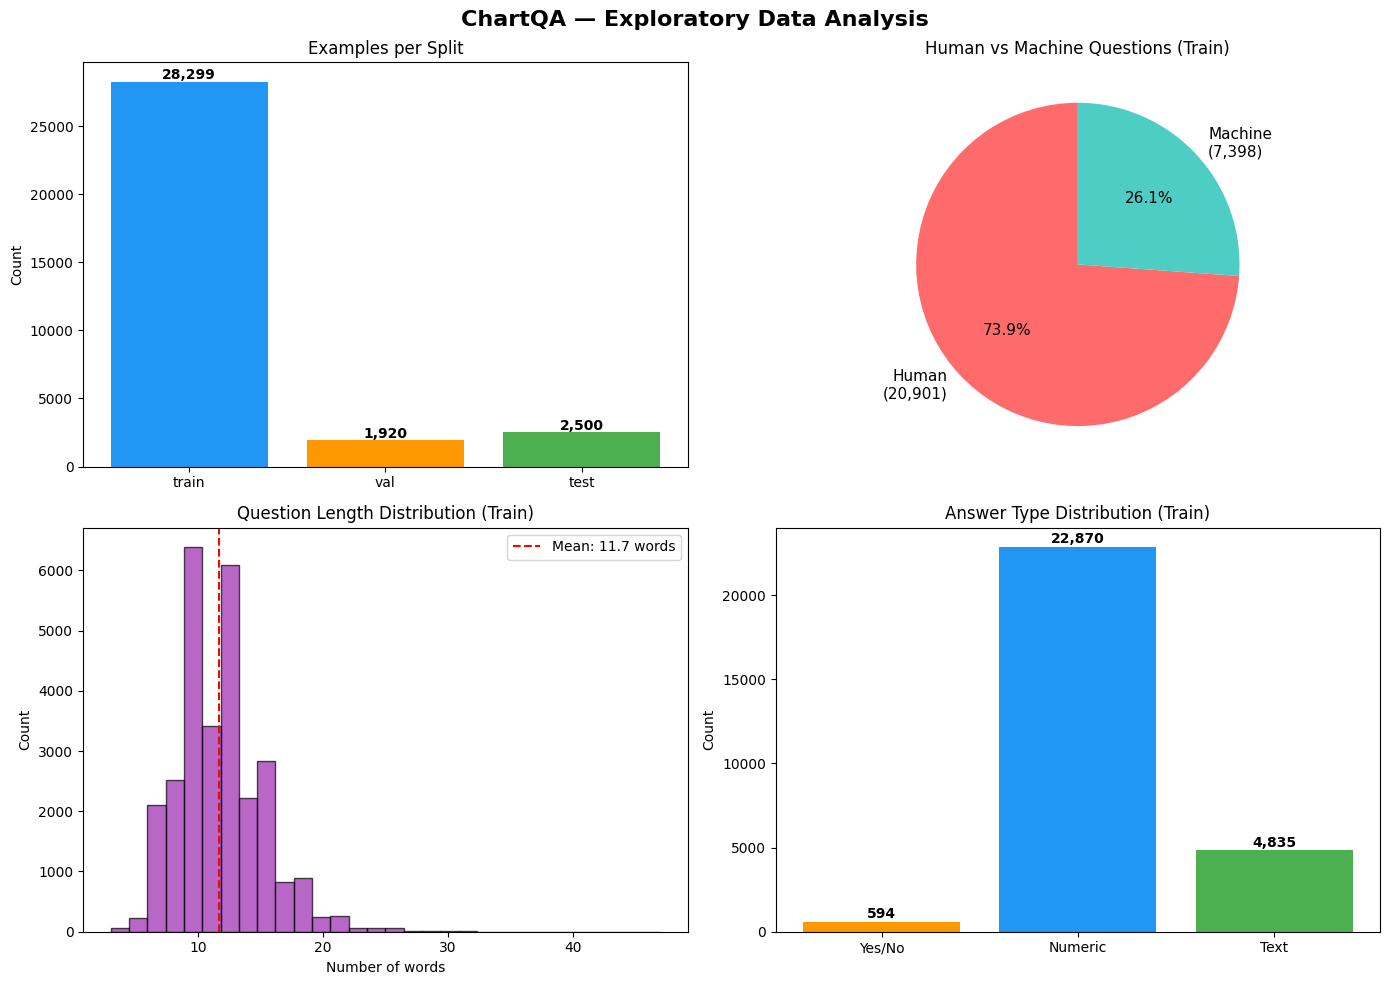

✓ Saved to outputs/chartqa_eda.png


In [ ]:
# ============================================================
# CELL 7: EDA — ChartQA Analysis
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ChartQA — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# --- 1. Split sizes ---
ax = axes[0, 0]
splits = ['train', 'val', 'test']
sizes = [len(chartqa[s]) for s in splits]
bars = ax.bar(splits, sizes, color=['#2196F3', '#FF9800', '#4CAF50'])
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{size:,}', ha='center', fontweight='bold')
ax.set_title('Examples per Split')
ax.set_ylabel('Count')

# --- 2. Human vs Machine generated questions ---
ax = axes[0, 1]
train_data = chartqa['train']
human_count = sum(1 for x in train_data if x['human_or_machine'] == 1)
machine_count = len(train_data) - human_count
ax.pie([human_count, machine_count],
       labels=[f'Human\n({human_count:,})', f'Machine\n({machine_count:,})'],
       colors=['#FF6B6B', '#4ECDC4'],
       autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 11})
ax.set_title('Human vs Machine Questions (Train)')

# --- 3. Question length distribution ---
ax = axes[1, 0]
q_lengths = [len(x['query'].split()) for x in train_data]
ax.hist(q_lengths, bins=30, color='#9C27B0', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(q_lengths), color='red', linestyle='--',
           label=f'Mean: {np.mean(q_lengths):.1f} words')
ax.set_title('Question Length Distribution (Train)')
ax.set_xlabel('Number of words')
ax.set_ylabel('Count')
ax.legend()

# --- 4. Answer type distribution ---
ax = axes[1, 1]
# Check if answers are Yes/No or other
answer_types = []
for x in train_data:
    ans = x['label'][0].lower().strip() if x['label'] else ''
    if ans in ['yes', 'no']:
        answer_types.append('Yes/No')
    elif ans.replace('.', '').replace(',', '').replace('%', '').replace('-', '').isdigit():
        answer_types.append('Numeric')
    else:
        answer_types.append('Text')

type_counts = Counter(answer_types)
colors_map = {'Yes/No': '#FF9800', 'Numeric': '#2196F3', 'Text': '#4CAF50'}
labels = list(type_counts.keys())
vals = [type_counts[l] for l in labels]
bars = ax.bar(labels, vals, color=[colors_map.get(l, '#999') for l in labels])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Answer Type Distribution (Train)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'chartqa_eda.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/chartqa_eda.png")

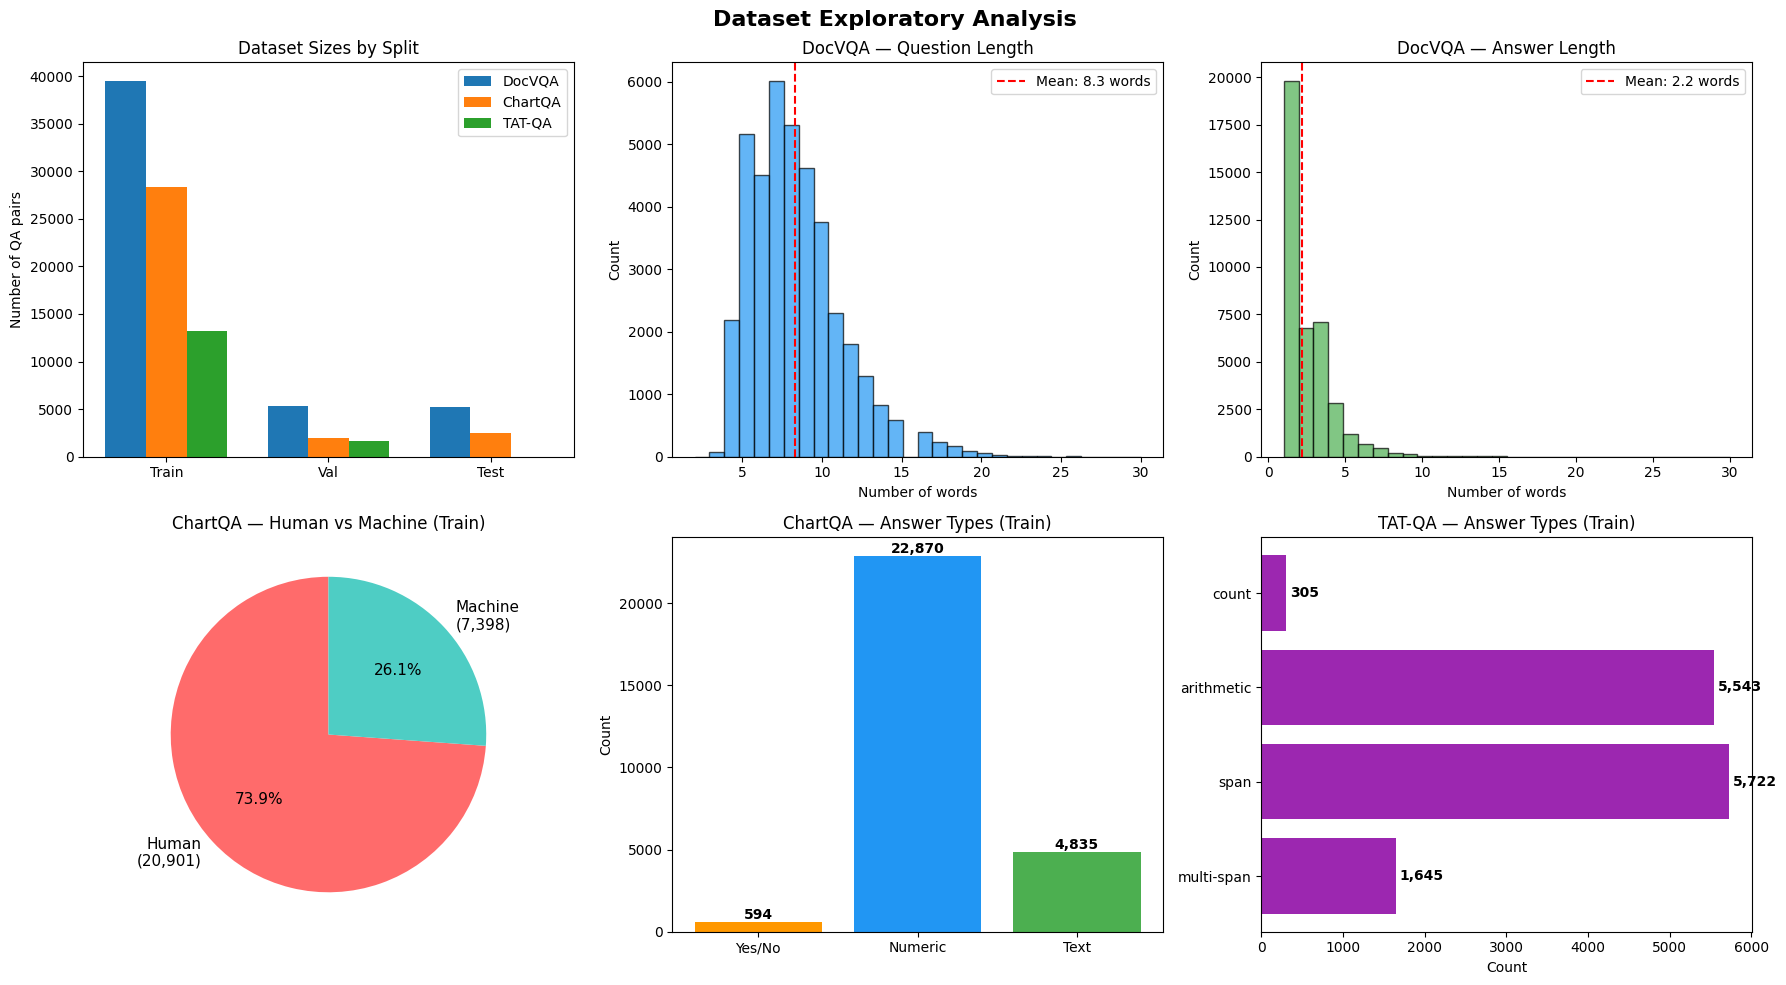

✓ Saved to outputs/dataset_eda.png


In [ ]:
# ============================================================
# CELL 7: EDA — DocVQA + ChartQA Analysis
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dataset Exploratory Analysis', fontsize=16, fontweight='bold')

# --- 1. Dataset split sizes ---
ax = axes[0, 0]
datasets_info = {
    'DocVQA': [len(docvqa['train']), len(docvqa['validation']), len(docvqa['test'])],
    'ChartQA': [len(chartqa['train']), len(chartqa['val']), len(chartqa['test'])],
    'TAT-QA': [train_q, dev_q, 0]
}
x = np.arange(3)
width = 0.25
for i, (name, vals) in enumerate(datasets_info.items()):
    bars = ax.bar(x + i*width, vals, width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels(['Train', 'Val', 'Test'])
ax.set_ylabel('Number of QA pairs')
ax.set_title('Dataset Sizes by Split')
ax.legend()

# --- 2. DocVQA question length distribution ---
ax = axes[0, 1]
dq_lengths = [len(ex['question'].split()) for ex in docvqa['train']]
ax.hist(dq_lengths, bins=30, color='#2196F3', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(dq_lengths), color='red', linestyle='--',
           label=f'Mean: {np.mean(dq_lengths):.1f} words')
ax.set_title('DocVQA — Question Length')
ax.set_xlabel('Number of words')
ax.set_ylabel('Count')
ax.legend()

# --- 3. DocVQA answer length distribution ---
ax = axes[0, 2]
da_lengths = [len(ex['answers'][0].split()) for ex in docvqa['train'] if ex['answers']]
ax.hist(da_lengths, bins=30, color='#4CAF50', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(da_lengths), color='red', linestyle='--',
           label=f'Mean: {np.mean(da_lengths):.1f} words')
ax.set_title('DocVQA — Answer Length')
ax.set_xlabel('Number of words')
ax.set_ylabel('Count')
ax.legend()

# --- 4. ChartQA human vs machine ---
ax = axes[1, 0]
human_count = sum(1 for x in chartqa['train'] if x['human_or_machine'] == 1)
machine_count = len(chartqa['train']) - human_count
ax.pie([human_count, machine_count],
       labels=[f'Human\n({human_count:,})', f'Machine\n({machine_count:,})'],
       colors=['#FF6B6B', '#4ECDC4'],
       autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 11})
ax.set_title('ChartQA — Human vs Machine (Train)')

# --- 5. ChartQA answer type distribution ---
ax = axes[1, 1]
answer_types = []
for x in chartqa['train']:
    ans = x['label'][0].lower().strip() if x['label'] else ''
    if ans in ['yes', 'no']:
        answer_types.append('Yes/No')
    elif ans.replace('.', '').replace(',', '').replace('%', '').replace('-', '').isdigit():
        answer_types.append('Numeric')
    else:
        answer_types.append('Text')
type_counts = Counter(answer_types)
colors_map = {'Yes/No': '#FF9800', 'Numeric': '#2196F3', 'Text': '#4CAF50'}
labels = list(type_counts.keys())
vals = [type_counts[l] for l in labels]
bars = ax.bar(labels, vals, color=[colors_map.get(l, '#999') for l in labels])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{v:,}', ha='center', fontweight='bold')
ax.set_title('ChartQA — Answer Types (Train)')
ax.set_ylabel('Count')

# --- 6. TAT-QA answer type distribution ---
ax = axes[1, 2]
tatqa_answer_types = []
for ctx in tatqa_train:
    for q in ctx.get('questions', []):
        tatqa_answer_types.append(q.get('answer_type', 'unknown'))
tat_counts = Counter(tatqa_answer_types)
ax.barh(list(tat_counts.keys()), list(tat_counts.values()), color='#9C27B0')
for i, (k, v) in enumerate(tat_counts.items()):
    ax.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')
ax.set_title('TAT-QA — Answer Types (Train)')
ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'dataset_eda.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/dataset_eda.png")

In [ ]:
# ============================================================
# CELL 9: Save Datasets to Drive (one-time, ~10 min)
# ============================================================
# After this, you'll load from Drive instead of re-downloading.
# This cell takes a while because it's writing ~6GB to Drive.
# ============================================================

import os

# Save DocVQA
docvqa_save_path = os.path.join(cfg.DOCVQA_DIR, 'docvqa_dataset')
if not os.path.exists(docvqa_save_path):
    print("Saving DocVQA to Drive... (this takes 5-10 minutes)")
    docvqa.save_to_disk(docvqa_save_path)
    print("✓ DocVQA saved")
else:
    print("✓ DocVQA already saved on Drive")

# Save ChartQA
chartqa_save_path = os.path.join(cfg.CHARTQA_DIR, 'chartqa_dataset')
if not os.path.exists(chartqa_save_path):
    print("Saving ChartQA to Drive... (this takes 2-3 minutes)")
    chartqa.save_to_disk(chartqa_save_path)
    print("✓ ChartQA saved")
else:
    print("✓ ChartQA already saved on Drive")

# TAT-QA is already on Drive (we copied the JSONs in Cell 6)
print("✓ TAT-QA already on Drive")

print("\n✓ All datasets saved! In future sessions, load with:")
print("  from datasets import load_from_disk")
print(f"  docvqa = load_from_disk('{docvqa_save_path}')")
print(f"  chartqa = load_from_disk('{chartqa_save_path}')")

Saving DocVQA to Drive... (this takes 5-10 minutes)


Saving the dataset (0/59 shards):   0%|          | 0/39463 [00:00<?, ? examples/s]

Saving the dataset (0/8 shards):   0%|          | 0/5349 [00:00<?, ? examples/s]

Saving the dataset (0/8 shards):   0%|          | 0/5188 [00:00<?, ? examples/s]

✓ DocVQA saved
Saving ChartQA to Drive... (this takes 2-3 minutes)


Saving the dataset (0/3 shards):   0%|          | 0/28299 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1920 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2500 [00:00<?, ? examples/s]

✓ ChartQA saved
✓ TAT-QA already on Drive

✓ All datasets saved! In future sessions, load with:
  from datasets import load_from_disk
  docvqa = load_from_disk('/content/drive/MyDrive/FinDocVQA/data/docvqa/docvqa_dataset')
  chartqa = load_from_disk('/content/drive/MyDrive/FinDocVQA/data/chartqa/chartqa_dataset')


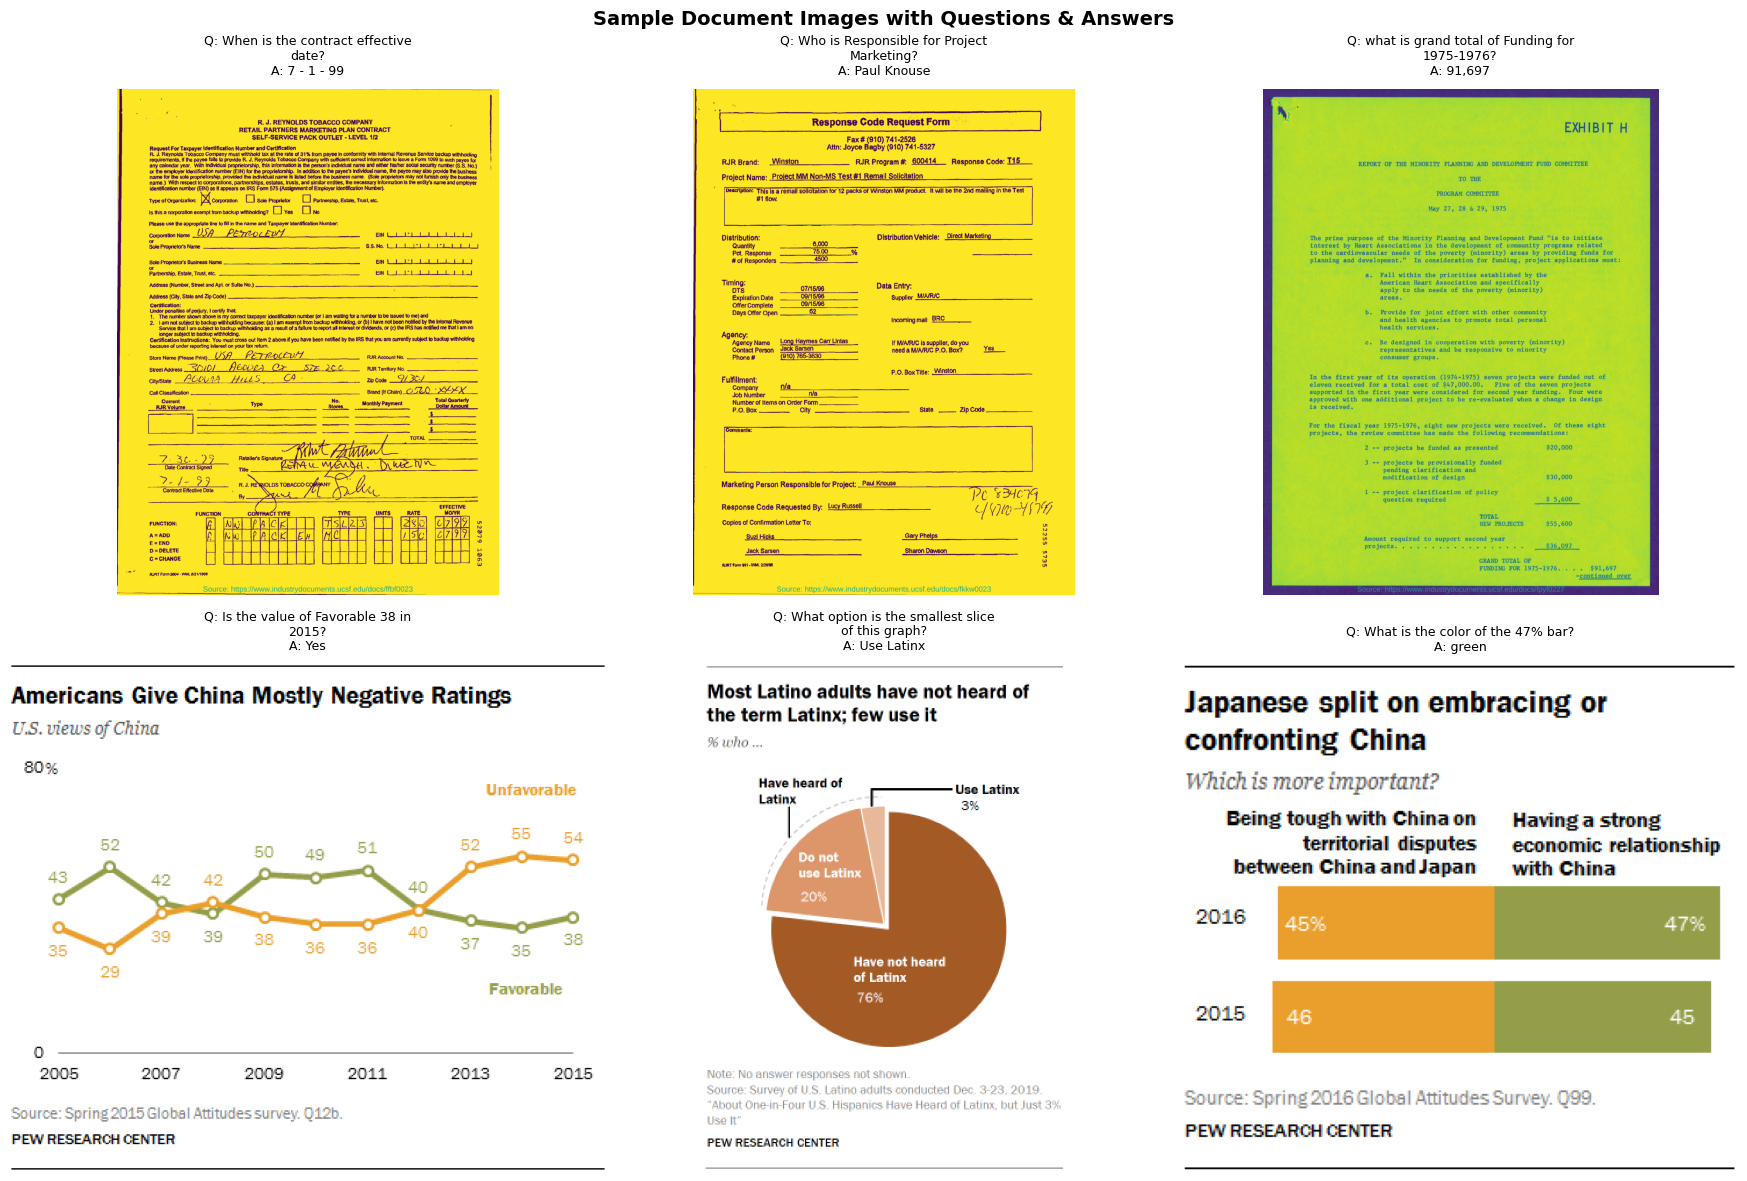

✓ Saved to outputs/sample_examples.png


In [ ]:
# ============================================================
# CELL 10: Visualize Sample Examples
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import textwrap

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Sample Document Images with Questions & Answers', fontsize=14, fontweight='bold')

# --- DocVQA samples (top row) ---
for i in range(3):
    ax = axes[0, i]
    idx = i * 1000  # spread out samples
    example = docvqa['train'][idx]

    # Handle image - could be PIL Image or dict with bytes
    img = example['image']
    if isinstance(img, dict) and 'bytes' in img:
        img = Image.open(BytesIO(img['bytes']))

    ax.imshow(img)
    ax.axis('off')

    q = textwrap.fill(example['question'], width=35)
    a = example['answers'][0] if example['answers'] else 'N/A'
    a = textwrap.fill(a, width=35)

    title = f"Q: {q}\nA: {a}"
    ax.set_title(title, fontsize=9, ha='center', pad=10)

    if i == 0:
        ax.set_ylabel('DocVQA', fontsize=12, fontweight='bold')

# --- ChartQA samples (bottom row) ---
for i in range(3):
    ax = axes[1, i]
    idx = i * 500
    example = chartqa['train'][idx]

    img = example['image']
    if isinstance(img, dict) and 'bytes' in img:
        img = Image.open(BytesIO(img['bytes']))

    ax.imshow(img)
    ax.axis('off')

    q = textwrap.fill(example['query'], width=35)
    a = example['label'][0] if example['label'] else 'N/A'
    a = textwrap.fill(str(a), width=35)

    title = f"Q: {q}\nA: {a}"
    ax.set_title(title, fontsize=9, ha='center', pad=10)

    if i == 0:
        ax.set_ylabel('ChartQA', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'sample_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/sample_examples.png")

In [ ]:
print(type(img), img.mode if hasattr(img, "mode") else None)

<class 'PIL.PngImagePlugin.PngImageFile'> RGB
